# RQ1 — VQC Adversarial Robustness on IDS Data (Phase 6)

Simulation-only. All data, results, and figures are written under
`/content/drive/MyDrive/QML_Cyber`.

Pipeline: NSL-KDD → one-hot+standardize → **PCA-8** → angle/amplitude encoding →
VQC vs tuned **MLP**/**SVM-RBF** (SVM attacked via a differentiable decision fn) →
shared **FGSM/PGD** white-box attack → metrics + figures → Phase-7 checker.


## 1. Mount Drive & set paths

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
BASE = '/content/drive/MyDrive/QML_Cyber'
for d in ('data', 'results', 'figures'):
    os.makedirs(f'{BASE}/{d}', exist_ok=True)
print('workspace:', BASE)

Mounted at /content/drive
workspace: /content/drive/MyDrive/QML_Cyber


## 2. Install dependencies
(8-qubit sim runs on CPU; a GPU runtime only speeds the classical baseline.)

In [2]:
!pip -q install pennylane torch scikit-learn pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 79.2 MB/s eta 0:00:00


## 3. Write the verified code + pre-registration into the workspace

In [3]:
import io, json, os, time, math, urllib.request, glob
import numpy as np, pandas as pd
import torch, torch.nn as nn
import pennylane as qml
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

N_QUBITS = 8
EPS_GRID = [0.0, 0.02, 0.05, 0.10, 0.15, 0.20]
COLS = ['duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
'root_shell','su_attempted','num_root','num_file_creations','num_shells',
'num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count',
'srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
'same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate',
'label','difficulty']
MIRROR = {'train':'https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.txt',
          'test': 'https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt'}

In [4]:
def load_nslkdd(base):
    out = {}
    for split, url in MIRROR.items():
        fp = f'{base}/data/nslkdd_{split}.csv'
        if os.path.exists(fp):
            df = pd.read_csv(fp)
        else:
            req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
            txt = urllib.request.urlopen(req, timeout=60).read().decode('utf-8', 'replace')
            df = pd.read_csv(io.StringIO(txt), header=None, names=COLS)
            df.to_csv(fp, index=False)
        df['y'] = (df['label'].astype(str).str.lower() != 'normal').astype(int)
        out[split] = df
    return out['train'], out['test']

def preprocess(train, test, n_comp=N_QUBITS):
    cats = ['protocol_type', 'service', 'flag']
    drop = cats + ['label', 'difficulty', 'y']
    num = [c for c in train.columns if c not in drop]
    Xtr = pd.concat([train[num], pd.get_dummies(train[cats])], axis=1)
    Xte = pd.concat([test[num], pd.get_dummies(test[cats])], axis=1).reindex(columns=Xtr.columns, fill_value=0)
    ytr, yte = train['y'].values, test['y'].values
    sc = StandardScaler().fit(Xtr.values.astype(float))
    pca = PCA(n_components=n_comp, random_state=0).fit(sc.transform(Xtr.values.astype(float)))
    mm = MinMaxScaler().fit(pca.transform(sc.transform(Xtr.values.astype(float))))
    tf = lambda X: mm.transform(pca.transform(sc.transform(X.values.astype(float)))).clip(0, 1)
    evr = float(pca.explained_variance_ratio_.sum())
    return tf(Xtr).astype(np.float32), ytr, tf(Xte).astype(np.float32), yte, evr

In [5]:
class TorchMLP(nn.Module):
    def __init__(self, d, h=(64, 32)):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d, h[0]), nn.ReLU(),
                                 nn.Linear(h[0], h[1]), nn.ReLU(), nn.Linear(h[1], 1))
    def forward(self, x):
        return self.net(x).squeeze(-1)

class TorchSVM(nn.Module):
    def __init__(self, svc):
        super().__init__()
        self.sv = torch.tensor(svc.support_vectors_, dtype=torch.float32)
        self.dual = torch.tensor(svc.dual_coef_.ravel(), dtype=torch.float32)
        self.b = float(svc.intercept_[0])
        self.gamma = float(getattr(svc, '_gamma', 1.0 / self.sv.shape[1]))
    def forward(self, x):
        k = torch.exp(-self.gamma * torch.cdist(x, self.sv) ** 2)
        return k @ self.dual + self.b

def make_vqc(encoding, n_layers=3):
    dev = qml.device('default.qubit', wires=N_QUBITS)
    @qml.qnode(dev, interface='torch', diff_method='backprop')
    def circuit(inputs, weights):
        if encoding == 'angle':
            qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')
        else:
            qml.AmplitudeEmbedding(inputs, wires=range(N_QUBITS), pad_with=0.0, normalize=True)
        qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
        return qml.expval(qml.PauliZ(0))
    shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=N_QUBITS)
    class VQC(nn.Module):
        def __init__(self):
            super().__init__()
            self.q = qml.qnn.TorchLayer(circuit, {'weights': shape})
            self.head = nn.Linear(1, 1)
        def forward(self, x):
            return self.head(self.q(x).unsqueeze(-1)).squeeze(-1)
    try:
        depth = int(qml.specs(circuit)(torch.zeros(N_QUBITS), torch.zeros(shape))['resources'].depth)
    except Exception:
        depth = None
    return VQC(), depth

In [6]:
def train_torch(model, X, y, epochs=40, lr=1e-2, bs=32, seed=0):
    torch.manual_seed(seed)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.BCEWithLogitsLoss()
    Xt, yt = torch.tensor(X), torch.tensor(y, dtype=torch.float32)
    n = len(Xt)
    for _ in range(epochs):
        perm = torch.randperm(n)
        for i in range(0, n, bs):
            idx = perm[i:i + bs]
            opt.zero_grad()
            lossf(model(Xt[idx]), yt[idx]).backward()
            opt.step()
    return model

def fgsm(model, X, y, eps):
    if eps == 0:
        return X.clone()
    X = X.clone().requires_grad_(True)
    g, = torch.autograd.grad(nn.BCEWithLogitsLoss()(model(X), y), X)
    return (X + eps * g.sign()).clamp(0, 1).detach()

def pgd(model, X, y, eps, steps=40):
    if eps == 0:
        return X.clone()
    alpha = 2.5 * eps / steps
    X0 = X.clone()
    Xa = (X0 + torch.empty_like(X0).uniform_(-eps, eps)).clamp(0, 1)
    for _ in range(steps):
        Xa.requires_grad_(True)
        g, = torch.autograd.grad(nn.BCEWithLogitsLoss()(model(Xa), y), Xa)
        Xa = (Xa + alpha * g.sign()).clamp(X0 - eps, X0 + eps).clamp(0, 1).detach()
    return Xa

def metrics_at(model, X, y):
    with torch.no_grad():
        prob = torch.sigmoid(model(X)).numpy()
    pred = (prob >= 0.5).astype(int)
    yn = y.numpy().astype(int)
    auc = roc_auc_score(yn, prob) if len(np.unique(yn)) > 1 else float('nan')
    return accuracy_score(yn, pred), f1_score(yn, pred, zero_division=0), auc

def eval_model(model, Xte, yte, attack, label, mtype, qubits, depth, backend):
    Xt, yt = torch.tensor(Xte), torch.tensor(yte, dtype=torch.float32)
    clean = metrics_at(model, Xt, yt)[0]
    rows = []
    for eps in EPS_GRID:
        acc, f1, auc = metrics_at(model, attack(model, Xt, yt, eps), yt)
        rows.append(dict(model=label, type=mtype, epsilon=eps, attack=attack.__name__,
            accuracy=acc, f1=f1, roc_auc=auc, clean_acc=clean, adv_acc=acc,
            qubits=qubits, depth=depth, shots=None, backend=backend))
    return rows

In [7]:
def plot(df, base, version):
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    for atk in df['attack'].unique():
        if atk == 'none':
            continue
        sub = df[df['attack'] == atk]
        plt.figure(figsize=(6, 4))
        for (mdl, enc), g in sub.groupby(['model', 'encoding']):
            gg = g.groupby('epsilon')['adv_acc'].mean()
            plt.plot(gg.index, gg.values, marker='o', label=mdl)
        plt.xlabel('epsilon (L-inf)'); plt.ylabel('adversarial accuracy')
        plt.title(f'Robustness vs attack strength ({atk.upper()})')
        plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout()
        plt.savefig(f'{base}/figures/advacc_vs_eps_{atk}_v{version}.png', dpi=130)
        plt.close()

def _seed_runs(Xtr, ytr, Xte, yte, t0, seeds, train_n, test_n, vqc_epochs):
    rows = []
    for seed in range(seeds):
        rng = np.random.default_rng(seed)
        tr = rng.choice(len(Xtr), min(train_n, len(Xtr)), replace=False)
        te = rng.choice(len(Xte), min(test_n, len(Xte)), replace=False)
        Xs, ys, Xv, yv = Xtr[tr], ytr[tr], Xte[te], yte[te]
        wc = lambda: round(time.time() - t0, 1)
        mlp = train_torch(TorchMLP(N_QUBITS), Xs, ys, epochs=60, seed=seed)
        svc = SVC(kernel='rbf', C=10, gamma='scale').fit(Xs, ys)
        svm = TorchSVM(svc)
        rf = RandomForestClassifier(n_estimators=200, random_state=seed).fit(Xs, ys)
        for atk in (fgsm, pgd):
            for m, lbl in ((mlp, 'MLP'), (svm, 'SVM-RBF')):
                rows += [dict(r, seed=seed, encoding='-', wall_clock_s=wc())
                         for r in eval_model(m, Xv, yv, atk, lbl, 'classical', None, None, 'cpu')]
        racc = accuracy_score(yv, rf.predict(Xv))
        rows.append(dict(model='RF', type='classical-context', epsilon=0.0, attack='none',
            accuracy=racc, f1=f1_score(yv, rf.predict(Xv)),
            roc_auc=roc_auc_score(yv, rf.predict_proba(Xv)[:, 1]),
            clean_acc=racc, adv_acc=racc, qubits=None, depth=None, shots=None,
            backend='cpu', seed=seed, encoding='-', wall_clock_s=wc()))
        for enc in ('angle', 'amplitude'):
            vqc, depth = make_vqc(enc)
            vqc = train_torch(vqc, Xs, ys, epochs=vqc_epochs, seed=seed)
            for atk in (fgsm, pgd):
                rows += [dict(r, seed=seed, encoding=enc, wall_clock_s=wc())
                         for r in eval_model(vqc, Xv, yv, atk, f'VQC-{enc}', 'quantum', N_QUBITS, depth, 'default.qubit')]
        print(f'seed {seed} done @ {wc()}s')
    return rows

def _save(rows, base, version, evr, dataset):
    df = pd.DataFrame(rows)
    df.to_csv(f'{base}/results/run_v{version}.csv', index=False)
    keys = ['model', 'type', 'encoding', 'attack', 'epsilon']
    aggdict = {c: 'mean' for c in ['accuracy', 'f1', 'roc_auc', 'clean_acc', 'adv_acc', 'wall_clock_s']}
    aggdict.update({c: 'first' for c in ['qubits', 'depth', 'shots', 'backend']})
    agg = df.groupby(keys, dropna=False).agg(aggdict).reset_index()
    cols = ['model', 'type', 'encoding', 'epsilon', 'attack', 'accuracy', 'f1', 'roc_auc',
            'clean_acc', 'adv_acc', 'qubits', 'depth', 'shots', 'wall_clock_s', 'backend']
    runs = [{k: (None if (k not in agg.columns or pd.isna(r.get(k))) else r[k]) for k in cols}
            for _, r in agg.iterrows()]
    json.dump({'runs': runs, '_pca_explained_variance': evr, '_claim_type': 'simulation-only',
               '_dataset': dataset}, open(f'{base}/results/metrics_v{version}.json', 'w'), indent=2)
    plot(df, base, version)
    print('wrote results + figures under', base)
    return df

def run(base, train_n=3000, test_n=1500, seeds=3, vqc_epochs=40, version=1):
    t0 = time.time()
    Xtr, ytr, Xte, yte, evr = preprocess(*load_nslkdd(base))
    print(f'NSL-KDD PCA-{N_QUBITS} explained variance = {evr:.3f}')
    rows = _seed_runs(Xtr, ytr, Xte, yte, t0, seeds, train_n, test_n, vqc_epochs)
    return _save(rows, base, version, evr, 'NSL-KDD')

In [8]:
def check_results(metrics_path, spec):
    data = json.load(open(metrics_path))
    runs = data['runs'] if isinstance(data, dict) and 'runs' in data else data
    fails, warns, oks = [], [], []
    rng = spec.get('metric_ranges', {'f1': [0, 1], 'accuracy': [0, 1], 'roc_auc': [0, 1]})
    perf = spec.get('suspicious_perfect_threshold', 0.999)
    for r in runs:
        tag = r.get('model', '?')
        for m, (lo, hi) in rng.items():
            v = r.get(m)
            if not isinstance(v, (int, float)):
                continue
            if math.isnan(v) or math.isinf(v):
                fails.append(f'{tag}:{m} NaN/inf')
            elif not (lo <= v <= hi):
                fails.append(f'{tag}:{m}={v} out of range')
            elif v >= perf:
                warns.append(f'{tag}:{m}={v:.3f} suspiciously perfect')
    (oks if any(x.get('type') == 'classical' for x in runs) else fails).append('classical baseline present')
    for r in runs:
        if r.get('type') == 'quantum':
            miss = [c for c in spec.get('required_resource_cols', []) if r.get(c) is None]
            (oks if not miss else fails).append(f"{r.get('model')} resources " + ('ok' if not miss else str(miss)))
    if spec.get('direction') == 'B' and spec.get('direction_B', {}).get('require_classical_under_same_attack'):
        ca = any(x.get('type') == 'classical' and x.get('adv_acc') is not None and x.get('epsilon', 0) > 0 for x in runs)
        (oks if ca else fails).append('classical attacked under same threat model')
    dr = spec.get('decision_rule', {})
    if dr:
        m = dr.get('metric', 'f1'); marg = dr.get('quantum_must_exceed_classical_by', 0)
        qs = [r[m] for r in runs if r.get('type') == 'quantum' and isinstance(r.get(m), (int, float))]
        cs = [r[m] for r in runs if r.get('type') == 'classical' and isinstance(r.get(m), (int, float))]
        if qs and cs:
            d = max(qs) - max(cs)
            verdict = 'ADVANTAGE' if d >= marg else 'NULL (honest, publishable)'
            oks.append(f'decision: quantum {m} {max(qs):.3f} vs classical {max(cs):.3f}, delta {d:.3f} -> {verdict}')
        else:
            warns.append('decision rule: need quantum and classical runs')
    print('FAILS:', fails or 'none')
    print('WARNS:', warns or 'none')
    for o in oks:
        print(' OK:', o)
    print('VERDICT:', 'FAIL' if fails else ('PASS-WITH-WARNINGS' if warns else 'PASS'))

SPEC = {'direction': 'B', 'claim_type': 'simulation-only', 'require_classical_baseline': True,
        'required_resource_cols': ['qubits', 'depth'], 'suspicious_perfect_threshold': 0.999,
        'metric_ranges': {'accuracy': [0, 1], 'f1': [0, 1], 'roc_auc': [0, 1], 'clean_acc': [0, 1], 'adv_acc': [0, 1]},
        'decision_rule': {'metric': 'adv_acc', 'quantum_must_exceed_classical_by': 0.02},
        'direction_B': {'require_classical_under_same_attack': True}}

In [9]:
# NSL-KDD study: quick 1-seed check, then full 5-seed run
df = run(BASE, seeds=1, vqc_epochs=30, version=0)
df = run(BASE, seeds=5, vqc_epochs=60, version=1)
check_results(f'{BASE}/results/metrics_v1.json', SPEC)

NSL-KDD PCA-8 explained variance = 0.267
seed 0 done @ 635.5s
wrote results + figures under /content/drive/MyDrive/QML_Cyber
NSL-KDD PCA-8 explained variance = 0.267
seed 0 done @ 878.4s
seed 1 done @ 1747.0s
seed 2 done @ 2619.5s
seed 3 done @ 3489.6s
seed 4 done @ 4360.5s
wrote results + figures under /content/drive/MyDrive/QML_Cyber
FAILS: none
WARNS: none
 OK: classical baseline present
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude resources ok
 OK: VQC-angle resources ok
 OK: VQC-angle resources ok
 OK: VQC-angle resources ok
 OK: VQC-angle resources ok
 OK: VQC-angle resources ok
 OK: VQC-angle resources ok
 OK: VQC-angle resources ok
 OK: VQC-angle resources o

/content/drive/MyDrive/QML_Cyber/figures/advacc_vs_eps_fgsm_errorbar_v1.png


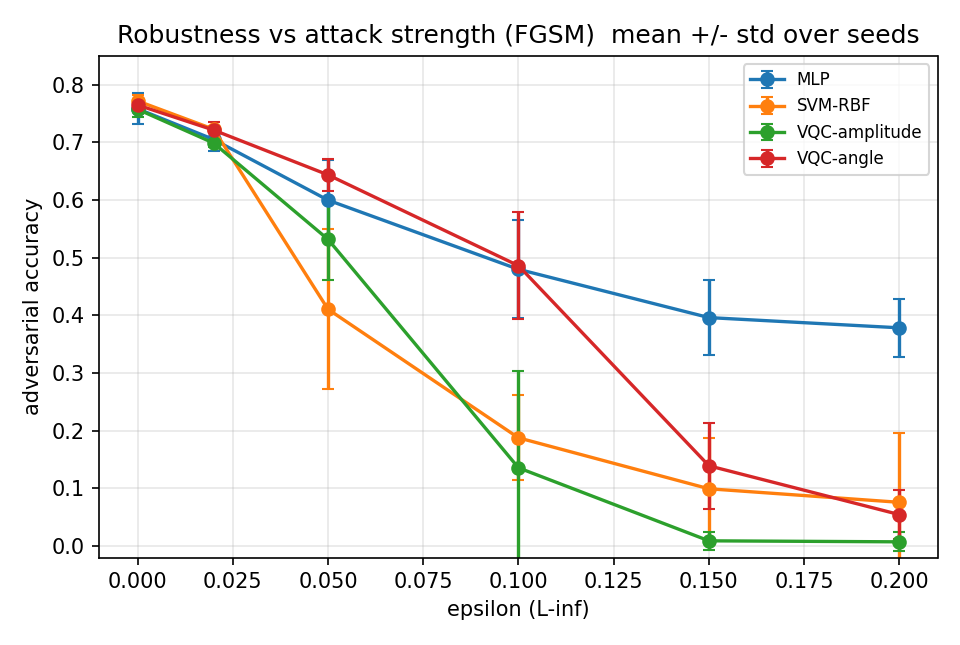

/content/drive/MyDrive/QML_Cyber/figures/advacc_vs_eps_pgd_errorbar_v1.png


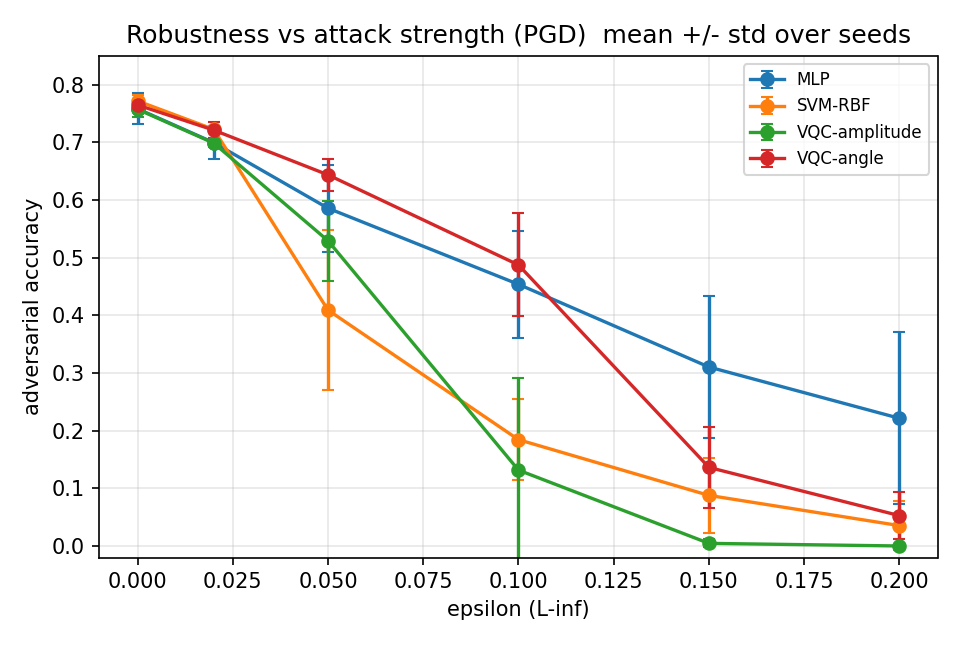

In [10]:
# Error-bar figures (mean +/- std over seeds) from run_v1.csv
ORDER = ['MLP', 'SVM-RBF', 'VQC-amplitude', 'VQC-angle']
COLOR = {'MLP': 'C0', 'SVM-RBF': 'C1', 'VQC-amplitude': 'C2', 'VQC-angle': 'C3'}

def plot_errorbars(base=BASE, version=1, use_sem=False):
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    df = pd.read_csv(f'{base}/results/run_v{version}.csv')
    df = df[df['attack'] != 'none']
    out = []
    for atk in sorted(df['attack'].unique()):
        sub = df[df['attack'] == atk]
        plt.figure(figsize=(6.4, 4.3))
        for mdl in ORDER:
            g = sub[sub['model'] == mdl]
            if g.empty:
                continue
            s = g.groupby('epsilon')['adv_acc'].agg(['mean', 'std', 'count']).reset_index()
            err = s['std'].fillna(0.0)
            if use_sem:
                err = err / np.sqrt(s['count'].clip(lower=1))
            plt.errorbar(s['epsilon'], s['mean'], yerr=err, marker='o', capsize=3,
                         linewidth=1.6, color=COLOR.get(mdl), label=mdl)
        band = '+/- SEM' if use_sem else '+/- std'
        plt.xlabel('epsilon (L-inf)'); plt.ylabel('adversarial accuracy')
        plt.title(f'Robustness vs attack strength ({atk.upper()})  mean {band} over seeds')
        plt.ylim(-0.02, 0.85); plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout()
        fp = f'{base}/figures/advacc_vs_eps_{atk}_errorbar_v{version}.png'
        plt.savefig(fp, dpi=150); plt.close(); out.append(fp)
    return out

from IPython.display import Image, display
for fp in plot_errorbars(BASE, version=1, use_sem=False):
    print(fp); display(Image(fp))

## CICIDS-2017 cross-check
Run the download cell, then the loader/run cells. Needs Kaggle credentials (Colab secrets KAGGLE_USERNAME / KAGGLE_KEY) or upload a zip into data/cicids2017/.

In [15]:
# Download CICIDS-2017 into the Drive folder (one-time). Skip if files already present.
import shutil
dest = f'{BASE}/data/cicids2017'; os.makedirs(dest, exist_ok=True)
if not glob.glob(f'{dest}/*.csv'):
    try:
        import kagglehub
        path = kagglehub.dataset_download('cicdataset/cicids2017')  # swap slug if it 404s
        for f in glob.glob(f'{path}/**/*.csv', recursive=True):
            shutil.copy(f, dest)
    except Exception as e:
        print('kaggle download failed:', e)
        # Fallback: upload a zip into data/cicids2017/, then unzip:
        import zipfile
        for z in glob.glob(f'{dest}/*.zip'):
            zipfile.ZipFile(z).extractall(dest)
print(len(glob.glob(f'{dest}/*.csv')), 'CSVs in', dest)

kaggle download failed: 403 Client Error.

You don't have permission to access resource at URL: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDataset. Please make sure you are authenticated if you are trying to access a private resource or a resource requiring consent.
0 CSVs in /content/drive/MyDrive/QML_Cyber/data/cicids2017


In [21]:
from google.colab import files
import os, shutil, json
files.upload()                          # choose the freshly downloaded kaggle.json
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
cfg = json.load(open('/root/.kaggle/kaggle.json'))
os.environ['KAGGLE_USERNAME'] = cfg['username']
os.environ['KAGGLE_KEY'] = cfg['key']
print('Kaggle auth set for', cfg['username'])

Saving kaggle.json to kaggle.json
Kaggle auth set for mdohidulbarik


In [25]:
import glob
print(len(glob.glob(f'{BASE}/data/cicids2017/*.csv')), 'CSVs')

0 CSVs


In [26]:
import os, glob, shutil
dest = f'{BASE}/data/cicids2017'; os.makedirs(dest, exist_ok=True)
import kagglehub
SLUG = 'cicdataset/cicids2017'      # <-- likely wrong; we'll confirm below
try:
    path = kagglehub.dataset_download(SLUG)
    print('downloaded to:', path)
    print('files there:', os.listdir(path)[:10])
    n = 0
    for f in glob.glob(f'{path}/**/*.csv', recursive=True):
        shutil.copy(f, dest); n += 1
    print('copied', n, 'CSVs ->', dest)
except Exception as e:
    print('ERROR:', repr(e))

ERROR: KaggleApiHTTPError("403 Client Error.\n\nYou don't have permission to access resource at URL: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDataset. Please make sure you are authenticated if you are trying to access a private resource or a resource requiring consent.")


In [24]:
import zipfile, glob
dest = f'{BASE}/data/cicids2017'
for z in glob.glob(f'{dest}/*.zip'):
    zipfile.ZipFile(z).extractall(dest)
print('CSVs now:', len(glob.glob(f'{dest}/*.csv')))

CSVs now: 0


In [27]:
import subprocess
print(subprocess.run(['kaggle','datasets','list','-s','cicids2017'],
                     capture_output=True, text=True).stdout)

ref                                                      title                                              size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------  ------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
ericanacletoribeiro/cicids2017-cleaned-and-preprocessed  CICIDS2017: Cleaned & Preprocessed            210143955  2025-01-12 12:02:31.110000           7519         54                1  
ernie55ernie/improved-cicids2017-and-csecicids2018       Improved CICIDS2017 and CSECICIDS2018       10985642855  2023-08-15 16:57:44.847000           2138         21        0.8235294  
devendra416/ddos-datasets                                DDoS Dataset                                 2880543869  2019-04-30 13:49:22.867000          13641        152        0.7058824  
mdalamintalukder/cicids2017                              CICIDS2017   

In [28]:
import kagglehub, glob, shutil, os
dest = f'{BASE}/data/cicids2017'; os.makedirs(dest, exist_ok=True)
SLUG = 'PASTE_REF_FROM_THE_LIST'          # e.g. something like 'dhoogla/cicids2017'
path = kagglehub.dataset_download(SLUG)
print('files:', os.listdir(path)[:10])
for f in glob.glob(f'{path}/**/*.csv', recursive=True):
    shutil.copy(f, dest)
print(len(glob.glob(f'{dest}/*.csv')), 'CSVs in', dest)

ValueError: Invalid dataset handle: PASTE_REF_FROM_THE_LIST

In [30]:
import kagglehub, glob, shutil, os
dest = f'{BASE}/data/cicids2017'; os.makedirs(dest, exist_ok=True)
SLUG = 'ericanacletoribeiro/cicids2017-cleaned-and-preprocessed'
path = kagglehub.dataset_download(SLUG)
print('downloaded to:', path)
print('files:', os.listdir(path)[:15])
for f in glob.glob(f'{path}/**/*.csv', recursive=True):
    shutil.copy(f, dest)
print(len(glob.glob(f'{dest}/*.csv')), 'CSVs in', dest)

100%|██████████| 200M/200M [00:01<00:00, 124MB/s]

Extracting files...


downloaded to: /root/.cache/kagglehub/datasets/ericanacletoribeiro/cicids2017-cleaned-and-preprocessed/versions/6
files: ['cicids2017_cleaned.csv']
1 CSVs in /content/drive/MyDrive/QML_Cyber/data/cicids2017


In [31]:
import pandas as pd, glob
f = glob.glob(f'{BASE}/data/cicids2017/*.csv')[0]
d = pd.read_csv(f, nrows=5)
print('shape:', d.shape)
print('columns:', list(d.columns))
# find the label-ish column and show its values
for c in d.columns:
    if 'label' in c.lower():
        print('label col:', repr(c), '->', pd.read_csv(f, usecols=[c]).iloc[:,0].unique()[:10])

shape: (5, 53)
columns: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'Average Packet Size', 'Subflow Fwd Bytes', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward', 'Active Mean', 'Active Max', 'Active Min', 'Idl

In [34]:
import pandas as pd, glob
f = glob.glob(f'{BASE}/data/cicids2017/*.csv')[0]
print(pd.read_csv(f, usecols=['Attack Type']).iloc[:,0].value_counts())

Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64


In [36]:
ID_COLS = {'flow id','source ip','src ip','destination ip','dst ip','source port',
           'src port','destination port','dst port','protocol','timestamp'}
LABEL_NAMES = {'label', 'attack type', 'class', 'attack', 'attack_type'}
BENIGN = {'BENIGN', 'NORMAL', 'NORMAL TRAFFIC'}

def load_cicids(base, subdir='data/cicids2017', test_size=0.3, seed=0, max_rows=40000):
    paths = sorted(glob.glob(f'{base}/{subdir}/*.csv'))
    if not paths:
        raise SystemExit(f'Put CICIDS-2017 CSVs in {base}/{subdir}/ first (run the download cell).')
    frames = []
    for p in paths:
        d = pd.read_csv(p, low_memory=False)
        d.columns = [c.strip().lower() for c in d.columns]
        frames.append(d)
    df = pd.concat(frames, ignore_index=True)
    lab = [c for c in df.columns if c in LABEL_NAMES]
    if not lab:
        raise SystemExit(f'No label column found. Columns: {list(df.columns)}')
    lab = lab[0]
    df['y'] = (~df[lab].astype(str).str.upper().str.strip().isin(BENIGN)).astype(int)
    drop = [c for c in df.columns if c in ID_COLS] + [lab]
    df = df.drop(columns=[c for c in drop if c in df.columns], errors='ignore')
    feat = [c for c in df.columns if c != 'y']
    df[feat] = df[feat].apply(pd.to_numeric, errors='coerce')
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    if max_rows and len(df) > max_rows:
        n = max_rows // 2
        df = pd.concat([g.sample(min(len(g), n), random_state=seed)
                        for _, g in df.groupby('y')]).reset_index(drop=True)
    tr, te = train_test_split(df, test_size=test_size, stratify=df['y'], random_state=seed)
    return tr.reset_index(drop=True), te.reset_index(drop=True)

def preprocess_numeric(train, test, n_comp=N_QUBITS):
    feat = [c for c in train.columns if c != 'y']
    Xtr, Xte = train[feat].values.astype(float), test[feat].values.astype(float)
    ytr, yte = train['y'].values, test['y'].values
    sc = StandardScaler().fit(Xtr)
    pca = PCA(n_components=n_comp, random_state=0).fit(sc.transform(Xtr))
    mm = MinMaxScaler().fit(pca.transform(sc.transform(Xtr)))
    tf = lambda X: mm.transform(pca.transform(sc.transform(X))).clip(0, 1)
    return tf(Xtr).astype(np.float32), ytr, tf(Xte).astype(np.float32), yte, float(pca.explained_variance_ratio_.sum())

def run_cicids(base, max_rows=40000, train_n=3000, test_n=1500, seeds=5, vqc_epochs=60, version=2):
    t0 = time.time()
    Xtr, ytr, Xte, yte, evr = preprocess_numeric(*load_cicids(base, max_rows=max_rows))
    print(f'CICIDS PCA-{N_QUBITS} explained variance = {evr:.3f} | '
          f'train={len(ytr)} test={len(yte)} attack_frac={ytr.mean():.3f}')
    rows = _seed_runs(Xtr, ytr, Xte, yte, t0, seeds, train_n, test_n, vqc_epochs)
    return _save(rows, base, version, evr, 'CICIDS-2017')

In [37]:
tr, te = load_cicids(BASE, max_rows=40000)
print('attack fraction:', round(tr['y'].mean(), 3), '| train rows:', len(tr))

attack fraction: 0.5 | train rows: 28000


In [38]:
df2 = run_cicids(BASE, seeds=1, vqc_epochs=30, version=8)

CICIDS PCA-8 explained variance = 0.777 | train=28000 test=12000 attack_frac=0.500
seed 0 done @ 591.5s
wrote results + figures under /content/drive/MyDrive/QML_Cyber


In [39]:
df2 = run_cicids(BASE, seeds=5, vqc_epochs=60, version=2)
check_results(f'{BASE}/results/metrics_v2.json', SPEC)
for fp in plot_errorbars(BASE, version=2, use_sem=False):
    print(fp)

CICIDS PCA-8 explained variance = 0.777 | train=28000 test=12000 attack_frac=0.500
seed 0 done @ 927.2s
seed 1 done @ 1809.7s
seed 2 done @ 2685.0s
seed 3 done @ 3559.8s
seed 4 done @ 4437.2s
wrote results + figures under /content/drive/MyDrive/QML_Cyber
FAILS: none
WARNS: none
 OK: classical baseline present
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude resources ok
 OK: VQC-angle resources ok
 OK: VQC-angle resources ok
 OK: VQC-angle resources ok
 OK: VQC-angle resources ok
 OK: VQC-angle resources ok
 OK: VQC-angle resources ok
 OK: VQC-angle resources ok
 OK: VQC-angle resources ok
 OK: VQC-angle resources ok
 OK: VQC-angle resources ok
 OK: VQC-angle resources 

/content/drive/MyDrive/QML_Cyber/figures/advacc_vs_eps_fgsm_errorbar_v2.png


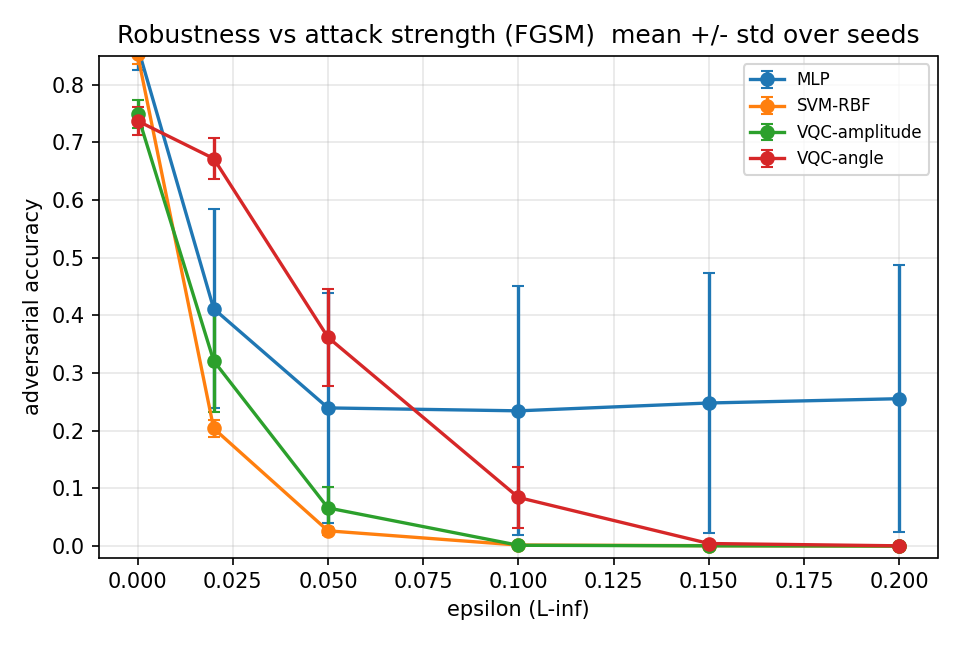

/content/drive/MyDrive/QML_Cyber/figures/advacc_vs_eps_fgsm_v2.png


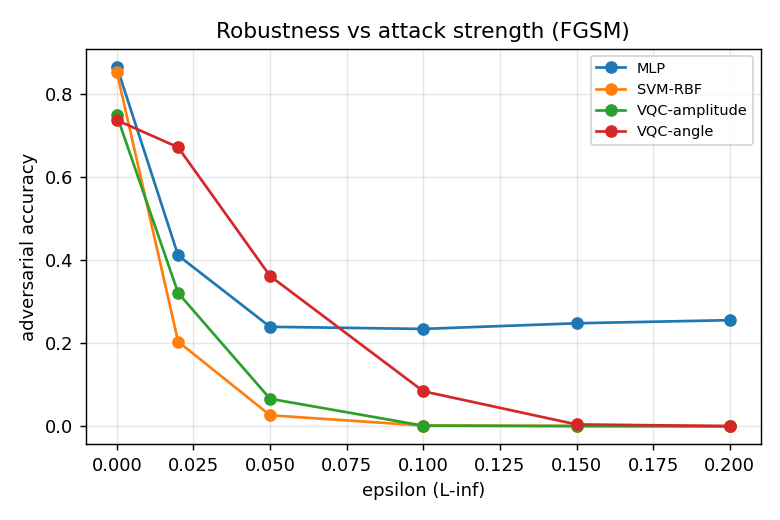

/content/drive/MyDrive/QML_Cyber/figures/advacc_vs_eps_pgd_errorbar_v2.png


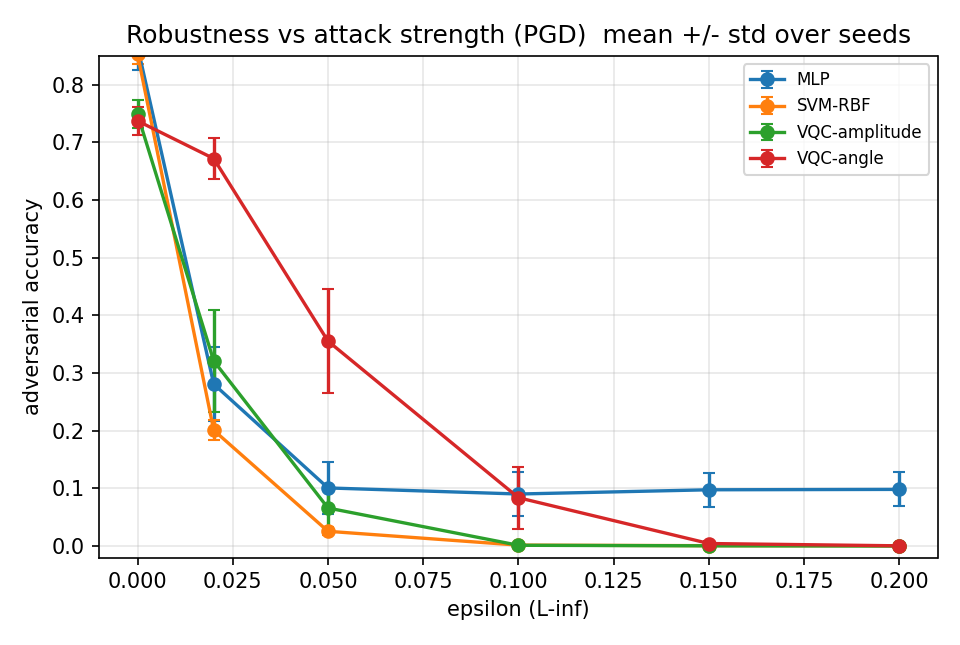

/content/drive/MyDrive/QML_Cyber/figures/advacc_vs_eps_pgd_v2.png


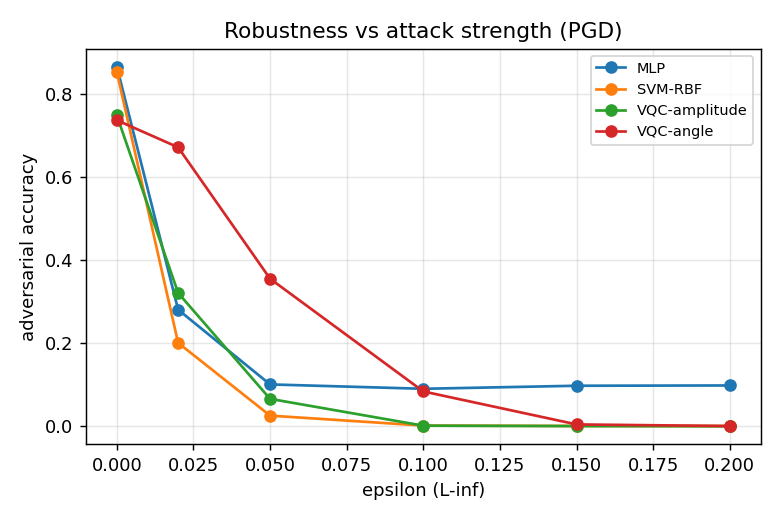

In [40]:
from IPython.display import Image, display
import glob
for f in sorted(glob.glob(f'{BASE}/figures/*_v2.png')):
    print(f); display(Image(f))

In [41]:
ORDER = ['MLP', 'SVM-RBF', 'VQC-amplitude', 'VQC-angle']
COLOR = {'MLP': 'C0', 'SVM-RBF': 'C1', 'VQC-amplitude': 'C2', 'VQC-angle': 'C3'}

def plot_errorbars(base=BASE, version=1, use_sem=False):
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    df = pd.read_csv(f'{base}/results/run_v{version}.csv')
    df = df[df['attack'] != 'none']
    out = []
    for atk in sorted(df['attack'].unique()):
        sub = df[df['attack'] == atk]
        plt.figure(figsize=(6.4, 4.3))
        for mdl in ORDER:
            g = sub[sub['model'] == mdl]
            if g.empty:
                continue
            s = g.groupby('epsilon')['adv_acc'].agg(['mean', 'std', 'count']).reset_index()
            err = s['std'].fillna(0.0)
            if use_sem:
                err = err / np.sqrt(s['count'].clip(lower=1))
            plt.errorbar(s['epsilon'], s['mean'], yerr=err, marker='o', capsize=3,
                         linewidth=1.6, color=COLOR.get(mdl), label=mdl)
        band = '+/- SEM' if use_sem else '+/- std'
        plt.xlabel('epsilon (L-inf)'); plt.ylabel('adversarial accuracy')
        plt.title(f'Robustness vs attack strength ({atk.upper()})  mean {band} over seeds')
        plt.ylim(-0.02, 1.0); plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout()
        fp = f'{base}/figures/advacc_vs_eps_{atk}_errorbar_v{version}.png'
        plt.savefig(fp, dpi=150); plt.close(); out.append(fp)
    return out

for fp in plot_errorbars(BASE, version=2, use_sem=False):
    print(fp)

/content/drive/MyDrive/QML_Cyber/figures/advacc_vs_eps_fgsm_errorbar_v2.png
/content/drive/MyDrive/QML_Cyber/figures/advacc_vs_eps_pgd_errorbar_v2.png


In [42]:
def make_vqc_noisy(encoding, p_gate=0.02, p_readout=0.02, n_layers=3):
    dev = qml.device('default.mixed', wires=N_QUBITS)          # density matrix -> real noise channels
    @qml.qnode(dev, interface='torch', diff_method='backprop')
    def circuit(inputs, weights):
        if encoding == 'angle':
            qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')
        else:
            qml.AmplitudeEmbedding(inputs, wires=range(N_QUBITS), pad_with=0.0, normalize=True)
        qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
        for w in range(N_QUBITS):
            qml.DepolarizingChannel(p_gate, wires=w)
        qml.BitFlip(p_readout, wires=0)
        return qml.expval(qml.PauliZ(0))
    shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=N_QUBITS)
    class VQC(nn.Module):
        def __init__(self):
            super().__init__(); self.q = qml.qnn.TorchLayer(circuit, {'weights': shape}); self.head = nn.Linear(1, 1)
        def forward(self, x): return self.head(self.q(x).unsqueeze(-1)).squeeze(-1)
    return VQC()

def _fwd(model, X, chunk=64):                                  # forward-only, chunked (bounds memory)
    out = []
    with torch.no_grad():
        for i in range(0, len(X), chunk):
            out.append(torch.sigmoid(model(torch.tensor(X[i:i+chunk]))).numpy())
    return np.concatenate(out)

def _mk_row(model, mtype, enc, eps, attack, p, yn, qubits, depth, backend, seed, clean):
    pred = (p >= 0.5).astype(int)
    return dict(model=model, type=mtype, encoding=enc, epsilon=eps, attack=attack,
        accuracy=accuracy_score(yn, pred), f1=f1_score(yn, pred, zero_division=0),
        roc_auc=(roc_auc_score(yn, p) if len(np.unique(yn)) > 1 else float('nan')),
        clean_acc=clean, adv_acc=accuracy_score(yn, pred),
        qubits=qubits, depth=depth, shots=None, backend=backend, seed=seed, wall_clock_s=None)

def run_noise_study(base, dataset='cicids', p_gate=0.02, p_readout=0.02,
                    train_n=3000, test_n=300, seeds=3, vqc_epochs=60, version=3):
    t0 = time.time()
    if dataset == 'cicids':
        Xtr, ytr, Xte, yte, evr = preprocess_numeric(*load_cicids(base, max_rows=40000))
    else:
        Xtr, ytr, Xte, yte, evr = preprocess(*load_nslkdd(base))
    print(f'{dataset} PCA-{N_QUBITS} EVR={evr:.3f} | noise p_gate={p_gate} p_readout={p_readout}')
    rows = []
    for seed in range(seeds):
        rng = np.random.default_rng(seed)
        tr = rng.choice(len(Xtr), min(train_n, len(Xtr)), replace=False)
        te = rng.choice(len(Xte), min(test_n, len(Xte)), replace=False)
        Xs, ys, Xv, yv = Xtr[tr], ytr[tr], Xte[te], yte[te]
        yn = yv.astype(int); Xt = torch.tensor(Xv); yt = torch.tensor(yv, dtype=torch.float32)
        wc = lambda: round(time.time() - t0, 1)
        # classical baselines (noise-free), white-box attacked, for reference + checker
        mlp = train_torch(TorchMLP(N_QUBITS), Xs, ys, epochs=60, seed=seed)
        svc = SVC(kernel='rbf', C=10, gamma='scale').fit(Xs, ys); svm = TorchSVM(svc)
        for m, lbl in ((mlp, 'MLP'), (svm, 'SVM-RBF')):
            cl = accuracy_score(yn, (_fwd(m, Xv) >= 0.5).astype(int))
            for attack, afn in (('fgsm', fgsm), ('pgd', pgd)):
                for eps in EPS_GRID:
                    Xadv = (Xt if eps == 0 else afn(m, Xt, yt, eps)).detach().numpy()
                    rows.append(_mk_row(lbl, 'classical', '-', eps, attack, _fwd(m, Xadv), yn, None, None, 'cpu', seed, cl))
        # VQC: train noiseless -> craft white-box -> transfer SAME weights to noisy -> eval forward-only
        for enc in ('angle', 'amplitude'):
            clean, depth = make_vqc(enc)
            clean = train_torch(clean, Xs, ys, epochs=vqc_epochs, seed=seed)
            noisy = make_vqc_noisy(enc, p_gate=p_gate, p_readout=p_readout)
            noisy.load_state_dict(clean.state_dict())
            cN = accuracy_score(yn, (_fwd(clean, Xv) >= 0.5).astype(int))
            cZ = accuracy_score(yn, (_fwd(noisy, Xv) >= 0.5).astype(int))
            for attack, afn in (('fgsm', fgsm), ('pgd', pgd)):
                for eps in EPS_GRID:
                    Xadv = (Xt if eps == 0 else afn(clean, Xt, yt, eps)).detach().numpy()
                    rows.append(_mk_row(f'VQC-{enc}', 'quantum', enc, eps, attack, _fwd(clean, Xadv), yn, N_QUBITS, depth, 'default.qubit', seed, cN))
                    rows.append(_mk_row(f'VQC-{enc}-noisy', 'quantum', enc, eps, attack, _fwd(noisy, Xadv), yn, N_QUBITS, depth, 'default.mixed', seed, cZ))
        print(f'seed {seed} done @ {wc()}s')
    return _save(rows, base, version, evr, f'{dataset}-noise-p{p_gate}')

cicids PCA-8 EVR=0.777 | noise p_gate=0.02 p_readout=0.02
seed 0 done @ 729.7s
wrote results + figures under /content/drive/MyDrive/QML_Cyber
cicids PCA-8 EVR=0.777 | noise p_gate=0.02 p_readout=0.02
seed 0 done @ 1861.7s
seed 1 done @ 3865.6s
seed 2 done @ 5707.9s
wrote results + figures under /content/drive/MyDrive/QML_Cyber
FAILS: none
WARNS: none
 OK: classical baseline present
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude resources ok
 OK: VQC-amplitude-noisy resources ok
 OK: VQC-amplitude-noisy resources ok
 OK: VQC-amplitude-noisy resources ok
 OK: VQC-amplitude-noisy resources ok
 OK: VQC-amplitude-noisy resources ok
 OK: VQC-amplitude-noisy resources ok
 OK

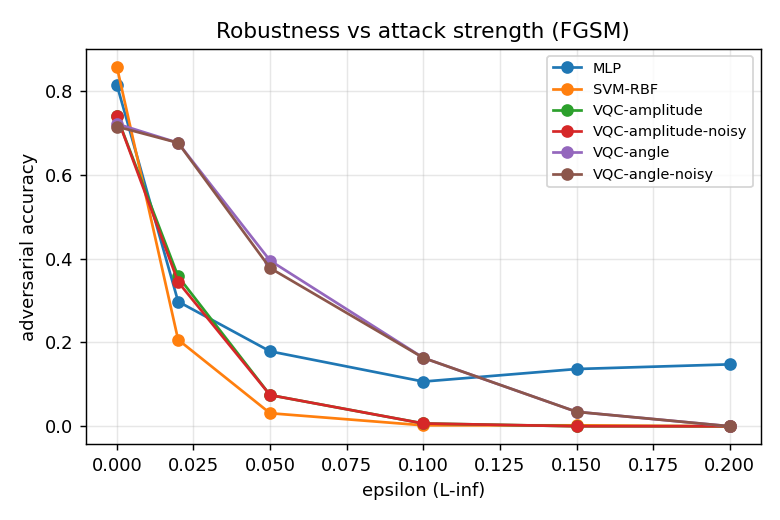

/content/drive/MyDrive/QML_Cyber/figures/advacc_vs_eps_pgd_v3.png


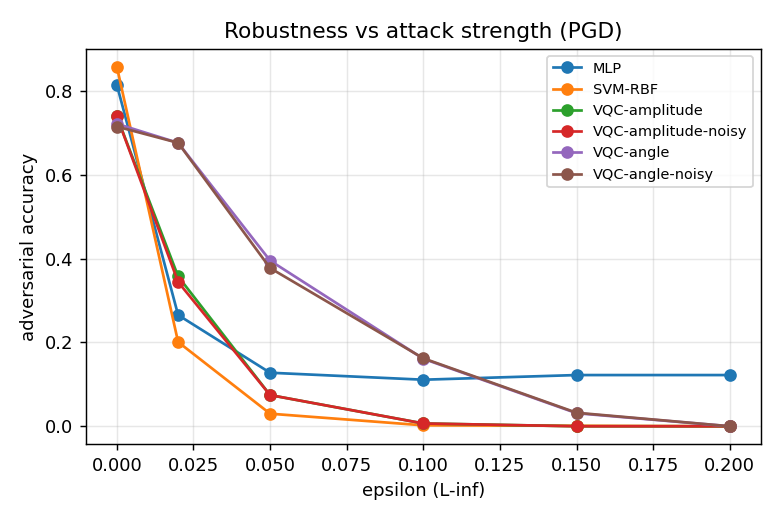

In [43]:
# quick 1-seed sanity check (small) — confirm it completes
_ = run_noise_study(BASE, dataset='cicids', test_n=120, seeds=1, vqc_epochs=20, version=9)

# real run: 3 seeds, ~1-1.5 hr on Colab
df3 = run_noise_study(BASE, dataset='cicids', p_gate=0.02, test_n=300, seeds=3, vqc_epochs=60, version=3)
check_results(f'{BASE}/results/metrics_v3.json', SPEC)

# figure (mean) is auto-saved by _save; show it
from IPython.display import Image, display
for f in sorted(glob.glob(f'{BASE}/figures/*_v3.png')):
    print(f); display(Image(f))

In [44]:
import json, glob
for v in (1, 2, 3):
    p = f'{BASE}/results/metrics_v{v}.json'
    print('='*20, p, '='*20)
    print(json.dumps(json.load(open(p)), indent=1))

==================== /content/drive/MyDrive/QML_Cyber/results/metrics_v1.json ====================
{
 "runs": [
  {
   "model": "MLP",
   "type": "classical",
   "encoding": "-",
   "epsilon": 0.0,
   "attack": "fgsm",
   "accuracy": 0.7585333333333333,
   "f1": 0.7382455133553709,
   "roc_auc": 0.9319085977532305,
   "clean_acc": 0.7585333333333333,
   "adv_acc": 0.7585333333333333,
   "qubits": null,
   "depth": null,
   "shots": null,
   "wall_clock_s": 1756.0400000000002,
   "backend": "cpu"
  },
  {
   "model": "MLP",
   "type": "classical",
   "encoding": "-",
   "epsilon": 0.02,
   "attack": "fgsm",
   "accuracy": 0.7051999999999999,
   "f1": 0.6715165571272287,
   "roc_auc": 0.703179900057523,
   "clean_acc": 0.7585333333333333,
   "adv_acc": 0.7051999999999999,
   "qubits": null,
   "depth": null,
   "shots": null,
   "wall_clock_s": 1756.0400000000002,
   "backend": "cpu"
  },
  {
   "model": "MLP",
   "type": "classical",
   "encoding": "-",
   "epsilon": 0.05,
   "attack": 

#MLP comparison:

In [45]:
import pandas as pd, numpy as np
from scipy import stats
for v, name in [(1,'NSL-KDD'), (2,'CICIDS-2017')]:
    df = pd.read_csv(f'{BASE}/results/run_v{v}.csv'); df = df[df.attack!='none']
    g = df.groupby(['attack','model','epsilon'])['adv_acc'].agg(['mean','std','count']).reset_index()
    print(f'\n===== {name}: mean ± std (per seed) =====')
    print(g.to_string(index=False))
    # significance of the angle vs MLP gap at eps=0.05, PGD
    for atk in ['fgsm','pgd']:
        a = df[(df.model=='VQC-angle')&(df.epsilon==0.05)&(df.attack==atk)]['adv_acc']
        m = df[(df.model=='MLP')&(df.epsilon==0.05)&(df.attack==atk)]['adv_acc']
        if len(a)>1 and len(m)>1:
            t,p = stats.ttest_ind(a, m, equal_var=False)
            print(f'{name} {atk} eps=0.05  angle {a.mean():.3f}±{a.std():.3f} vs MLP {m.mean():.3f}±{m.std():.3f}  Welch p={p:.3f}')


===== NSL-KDD: mean ± std (per seed) =====
attack         model  epsilon     mean      std  count
  fgsm           MLP     0.00 0.758533 0.026631      5
  fgsm           MLP     0.02 0.705200 0.020382      5
  fgsm           MLP     0.05 0.600000 0.070467      5
  fgsm           MLP     0.10 0.480000 0.085042      5
  fgsm           MLP     0.15 0.396267 0.065696      5
  fgsm           MLP     0.20 0.378533 0.050225      5
  fgsm       SVM-RBF     0.00 0.772133 0.010619      5
  fgsm       SVM-RBF     0.02 0.722933 0.005387      5
  fgsm       SVM-RBF     0.05 0.410800 0.138332      5
  fgsm       SVM-RBF     0.10 0.187733 0.074010      5
  fgsm       SVM-RBF     0.15 0.099333 0.087220      5
  fgsm       SVM-RBF     0.20 0.075867 0.119754      5
  fgsm VQC-amplitude     0.00 0.757600 0.013120      5
  fgsm VQC-amplitude     0.02 0.698933 0.007595      5
  fgsm VQC-amplitude     0.05 0.532000 0.071220      5
  fgsm VQC-amplitude     0.10 0.135733 0.167688      5
  fgsm VQC-amplitude 

#Cell A — setup, feature selection, models, attacks

In [51]:
import glob, pandas as pd
files = glob.glob("/content/drive/MyDrive/QML_Cyber/data/cicids2017/**/*.csv", recursive=True)
print("CICIDS CSVs found:", files)
df0 = pd.read_csv(files[0], nrows=5)
df0.columns = df0.columns.str.strip()
print("\nColumns:\n", list(df0.columns))

CICIDS CSVs found: ['/content/drive/MyDrive/QML_Cyber/data/cicids2017/cicids2017_cleaned.csv']

Columns:
 ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'Average Packet Size', 'Subflow Fwd Bytes', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data

In [52]:
# === Rebuild CICIDS-2017 PCA-8 (reads the cicids2017 FOLDER, matches v2) ===
import numpy as np, pandas as pd, glob
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

files = sorted(glob.glob("/content/drive/MyDrive/QML_Cyber/data/cicids2017/**/*.csv", recursive=True))
print("loading", len(files), "file(s)")
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
df.columns = df.columns.str.strip()

LABEL  = "Attack Type"          # <-- change if inspection shows otherwise
BENIGN = "Normal Traffic"       # <-- change if inspection shows otherwise
assert LABEL in df.columns, f"Label not found. Columns are: {list(df.columns)}"

y = (df[LABEL].astype(str).str.strip() != BENIGN).astype(np.float32).values  # benign=0, attack=1
X = df.drop(columns=[LABEL]).select_dtypes(include=[np.number]).copy()
X = X.replace([np.inf, -np.inf], np.nan).dropna(axis=1, how="any").values.astype(np.float32)

rng = np.random.default_rng(0)
pos, neg = np.where(y == 1)[0], np.where(y == 0)[0]
k = min(len(pos), len(neg), 6000)
sel = np.concatenate([rng.choice(pos, k, replace=False), rng.choice(neg, k, replace=False)])
X, y = X[sel], y[sel]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
sc  = StandardScaler().fit(X_tr)
pca = PCA(n_components=8, random_state=0).fit(sc.transform(X_tr))
mm  = MinMaxScaler().fit(pca.transform(sc.transform(X_tr)))
def prep(A): return mm.transform(pca.transform(sc.transform(A))).clip(0, 1).astype(np.float32)
X_tr, X_te = prep(X_tr), prep(X_te)

d = "/content/drive/MyDrive/QML_Cyber/data"
np.save(f"{d}/Xtr.npy", X_tr); np.save(f"{d}/Xte.npy", X_te)
np.save(f"{d}/ytr.npy", y_tr); np.save(f"{d}/yte.npy", y_te)
print("EVR(8) =", round(float(pca.explained_variance_ratio_.sum()), 3),
      "| shapes", X_tr.shape, X_te.shape, "| attack frac", round(float(y_tr.mean()), 3))

loading 1 file(s)
EVR(8) = 0.734 | shapes (8400, 8) (3600, 8) | attack frac 0.5


In [53]:
# === Item 1: non-degenerate amplitude encoding (version=4) — Cell A ===
# Assumes X_tr, X_te, y_tr, y_te already in memory: PCA-8 features scaled to [0,1],
# labels in {0,1}. These are the SAME arrays you used for metrics_v2 (CICIDS-2017).
import numpy as np, torch, torch.nn.functional as F, pennylane as qml, json, pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from scipy.stats import ttest_ind

n_qubits, L = 8, 3
N_TRAIN, N_TEST = 800, 400          # subsets for tractable VQC attack eval; raise for final
EPS = [0.0, 0.02, 0.05, 0.10, 0.15, 0.20]
SEEDS = [0, 1, 2, 3, 4]
EPOCHS = 40
dev = qml.device("default.qubit", wires=n_qubits)

Xtr_full = np.asarray(X_tr, dtype=np.float32); ytr_full = np.asarray(y_tr, dtype=np.float32)
Xte_full = np.asarray(X_te, dtype=np.float32); yte_full = np.asarray(y_te, dtype=np.float32)

# ---- Build the dense amplitude feature map: top-256 polynomial monomials by train variance ----
poly = PolynomialFeatures(degree=4, include_bias=True).fit(Xtr_full)
M = poly.transform(Xtr_full)                       # [N, n_mono]
powers_all = poly.powers_.astype(np.float32)       # [n_mono, 8]
var = M.var(axis=0)
keep = np.argsort(var)[::-1][:256]                 # 256 highest-variance monomials
POWERS   = torch.tensor(powers_all[keep])          # [256, 8]
MONO_MEAN = torch.tensor(M[:, keep].mean(0), dtype=torch.float32)
MONO_STD  = torch.tensor(M[:, keep].std(0) + 1e-8, dtype=torch.float32)
pop_frac = float((var[keep] > 1e-12).mean())
print(f"Dense amplitude: {int((var[keep]>1e-12).sum())}/256 amplitudes populated "
      f"({pop_frac*100:.1f}%) vs 8/256 (3.1%) in the degenerate version.")

def amp_dense(x):                                  # x:[B,8] -> [B,256], differentiable
    mono = torch.prod(x.clamp(0, 1).unsqueeze(1).pow(POWERS), dim=2)
    return (mono - MONO_MEAN) / MONO_STD

def amp_degen(x):                                  # original: pad 8 -> 256 (248 zeros)
    return F.pad(x, (0, 256 - n_qubits))

# ---- QNodes (batched via broadcasting) ----
@qml.qnode(dev, interface="torch", diff_method="backprop")
def qn_angle(inputs, w):
    qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation="Y")
    qml.StronglyEntanglingLayers(w, wires=range(n_qubits))
    return qml.expval(qml.PauliZ(0))

@qml.qnode(dev, interface="torch", diff_method="backprop")
def qn_amp(inputs, w):
    qml.AmplitudeEmbedding(inputs, wires=range(n_qubits), normalize=True)
    qml.StronglyEntanglingLayers(w, wires=range(n_qubits))
    return qml.expval(qml.PauliZ(0))

class VQC(torch.nn.Module):
    def __init__(self, kind, seed=0):
        super().__init__()
        self.kind = kind
        g = torch.Generator().manual_seed(seed)
        shp = qml.StronglyEntanglingLayers.shape(n_layers=L, n_wires=n_qubits)
        self.w = torch.nn.Parameter(0.1 * torch.randn(*shp, generator=g))
        self.a = torch.nn.Parameter(torch.tensor(1.0))
        self.b = torch.nn.Parameter(torch.tensor(0.0))
    def forward(self, x):
        if self.kind == "angle":
            ex = qn_angle(x * np.pi, self.w)               # [0,1] -> [0,pi] rotations
        elif self.kind == "amp_dense":
            ex = qn_amp(amp_dense(x), self.w)
        else:                                              # amp_degen
            ex = qn_amp(amp_degen(x), self.w)
        ex = torch.as_tensor(ex).reshape(-1).float()
        return torch.sigmoid(self.a * ex + self.b)

def fgsm(model, x, y, eps):
    if eps == 0: return x
    x = x.clone().detach().requires_grad_(True)
    loss = F.binary_cross_entropy(model(x), y)
    g, = torch.autograd.grad(loss, x)
    return (x + eps * g.sign()).clamp(0, 1).detach()

def pgd(model, x, y, eps, steps=40):
    if eps == 0: return x
    alpha = 2.5 * eps / steps
    xa = (x + torch.empty_like(x).uniform_(-eps, eps)).clamp(0, 1).detach()
    for _ in range(steps):
        xa.requires_grad_(True)
        loss = F.binary_cross_entropy(model(xa), y)
        g, = torch.autograd.grad(loss, xa)
        xa = (xa + alpha * g.sign())
        xa = torch.min(torch.max(xa, x - eps), x + eps).clamp(0, 1).detach()
    return xa

print("Cell A ready.")

Dense amplitude: 256/256 amplitudes populated (100.0%) vs 8/256 (3.1%) in the degenerate version.
Cell A ready.


#Cell B — train, attack, save, report

In [54]:
# === Item 1 — Cell B: run 3 encodings x 2 attacks x grid x seeds, save v4 ===
MODELS = ["VQC-angle", "VQC-amplitude-dense", "VQC-amplitude-degenerate"]
KIND   = {"VQC-angle": "angle", "VQC-amplitude-dense": "amp_dense",
          "VQC-amplitude-degenerate": "amp_degen"}
results = {a: {m: {f"{e:.2f}": [] for e in EPS} for m in MODELS} for a in ["fgsm", "pgd"]}
rows = []

for seed in SEEDS:
    np.random.seed(seed); torch.manual_seed(seed)
    itr = np.random.choice(len(Xtr_full), min(N_TRAIN, len(Xtr_full)), replace=False)
    ite = np.random.choice(len(Xte_full), min(N_TEST,  len(Xte_full)), replace=False)
    Xtr = torch.tensor(Xtr_full[itr]); ytr = torch.tensor(ytr_full[itr])
    Xte = torch.tensor(Xte_full[ite]); yte = torch.tensor(yte_full[ite])

    for m in MODELS:
        model = VQC(KIND[m], seed=seed)
        opt = torch.optim.Adam(model.parameters(), lr=0.05)
        for _ in range(EPOCHS):
            opt.zero_grad()
            loss = F.binary_cross_entropy(model(Xtr), ytr)
            loss.backward(); opt.step()
        model.eval()
        for attack, fn in [("fgsm", fgsm), ("pgd", pgd)]:
            for e in EPS:
                xadv = fn(model, Xte, yte, e)
                with torch.no_grad():
                    acc = ((model(xadv) > 0.5).float() == yte).float().mean().item()
                results[attack][m][f"{e:.2f}"].append(acc)
                rows.append(dict(attack=attack, model=m, epsilon=e, seed=seed, acc=acc))
        print(f"seed {seed} | {m:28s} clean={results['pgd'][m]['0.00'][-1]:.3f}")

# ---- save ----
base = "/content/drive/MyDrive/QML_Cyber/results"
import os; os.makedirs(base, exist_ok=True)
json.dump({"populated_fraction": pop_frac, "results": results},
          open(f"{base}/metrics_v4.json", "w"), indent=2)
pd.DataFrame(rows).to_csv(f"{base}/run_v4.csv", index=False)

# ---- report: mean±std table + significance at eps=0.05 ----
df = pd.DataFrame(rows)
tbl = (df.groupby(["attack", "model", "epsilon"])["acc"]
         .agg(["mean", "std"]).round(3).reset_index())
print("\n===== version 4 (non-degenerate amplitude) mean±std ====="); print(tbl.to_string(index=False))

def welch(attack, m1, m2, e=0.05):
    a = df[(df.attack==attack)&(df.model==m1)&(df.epsilon==e)].acc
    b = df[(df.attack==attack)&(df.model==m2)&(df.epsilon==e)].acc
    p = ttest_ind(a, b, equal_var=False).pvalue
    print(f"{attack} eps={e}: {m1} {a.mean():.3f}±{a.std():.3f} vs "
          f"{m2} {b.mean():.3f}±{b.std():.3f}  Welch p={p:.3f}")

print()
for atk in ["fgsm", "pgd"]:
    welch(atk, "VQC-angle", "VQC-amplitude-dense")
    welch(atk, "VQC-amplitude-dense", "VQC-amplitude-degenerate")

seed 0 | VQC-angle                    clean=0.725
seed 0 | VQC-amplitude-dense          clean=0.755
seed 0 | VQC-amplitude-degenerate     clean=0.723
seed 1 | VQC-angle                    clean=0.710
seed 1 | VQC-amplitude-dense          clean=0.743
seed 1 | VQC-amplitude-degenerate     clean=0.705
seed 2 | VQC-angle                    clean=0.762
seed 2 | VQC-amplitude-dense          clean=0.772
seed 2 | VQC-amplitude-degenerate     clean=0.757
seed 3 | VQC-angle                    clean=0.748
seed 3 | VQC-amplitude-dense          clean=0.750
seed 3 | VQC-amplitude-degenerate     clean=0.743
seed 4 | VQC-angle                    clean=0.777
seed 4 | VQC-amplitude-dense          clean=0.757
seed 4 | VQC-amplitude-degenerate     clean=0.772

===== version 4 (non-degenerate amplitude) mean±std =====
attack                    model  epsilon  mean   std
  fgsm VQC-amplitude-degenerate     0.00 0.740 0.027
  fgsm VQC-amplitude-degenerate     0.02 0.711 0.028
  fgsm VQC-amplitude-degenerate 

#Cell C — second ansatz (BasicEntanglerLayers), version=5

In [55]:
# === Item 5: second ansatz (BasicEntanglerLayers) — Cell C ===
# Run AFTER Cell A + Cell B (reuses amp_dense, amp_degen, fgsm, pgd, EPS, SEEDS,
# Xtr_full/Xte_full/ytr_full/yte_full, n_qubits, N_TRAIN, N_TEST, EPOCHS, dev).
import numpy as np, torch, torch.nn.functional as F, pennylane as qml, json, os, pandas as pd
from scipy.stats import ttest_ind

L2 = 3   # BasicEntanglerLayers depth (one rotation + CNOT ring per layer)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def qn_angle_be(inputs, w):
    qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation="Y")
    qml.BasicEntanglerLayers(w, wires=range(n_qubits))
    return qml.expval(qml.PauliZ(0))

@qml.qnode(dev, interface="torch", diff_method="backprop")
def qn_amp_be(inputs, w):
    qml.AmplitudeEmbedding(inputs, wires=range(n_qubits), normalize=True)
    qml.BasicEntanglerLayers(w, wires=range(n_qubits))
    return qml.expval(qml.PauliZ(0))

class VQC_BE(torch.nn.Module):
    def __init__(self, kind, seed=0):
        super().__init__()
        self.kind = kind
        g = torch.Generator().manual_seed(seed)
        shp = qml.BasicEntanglerLayers.shape(n_layers=L2, n_wires=n_qubits)  # [L2, n_qubits]
        self.w = torch.nn.Parameter(0.1 * torch.randn(*shp, generator=g))
        self.a = torch.nn.Parameter(torch.tensor(1.0))
        self.b = torch.nn.Parameter(torch.tensor(0.0))
    def forward(self, x):
        if self.kind == "angle":
            ex = qn_angle_be(x * np.pi, self.w)
        elif self.kind == "amp_dense":
            ex = qn_amp_be(amp_dense(x), self.w)
        else:
            ex = qn_amp_be(amp_degen(x), self.w)
        ex = torch.as_tensor(ex).reshape(-1).float()
        return torch.sigmoid(self.a * ex + self.b)

MODELS = ["VQC-angle", "VQC-amplitude-dense", "VQC-amplitude-degenerate"]
KIND   = {"VQC-angle": "angle", "VQC-amplitude-dense": "amp_dense",
          "VQC-amplitude-degenerate": "amp_degen"}
results = {a: {m: {f"{e:.2f}": [] for e in EPS} for m in MODELS} for a in ["fgsm", "pgd"]}
rows = []

for seed in SEEDS:
    np.random.seed(seed); torch.manual_seed(seed)
    itr = np.random.choice(len(Xtr_full), min(N_TRAIN, len(Xtr_full)), replace=False)
    ite = np.random.choice(len(Xte_full), min(N_TEST,  len(Xte_full)), replace=False)
    Xtr = torch.tensor(Xtr_full[itr]); ytr = torch.tensor(ytr_full[itr])
    Xte = torch.tensor(Xte_full[ite]); yte = torch.tensor(yte_full[ite])
    for m in MODELS:
        model = VQC_BE(KIND[m], seed=seed)
        opt = torch.optim.Adam(model.parameters(), lr=0.05)
        for _ in range(EPOCHS):
            opt.zero_grad()
            F.binary_cross_entropy(model(Xtr), ytr).backward(); opt.step()
        model.eval()
        for attack, fn in [("fgsm", fgsm), ("pgd", pgd)]:
            for e in EPS:
                xadv = fn(model, Xte, yte, e)
                with torch.no_grad():
                    acc = ((model(xadv) > 0.5).float() == yte).float().mean().item()
                results[attack][m][f"{e:.2f}"].append(acc)
                rows.append(dict(attack=attack, model=m, epsilon=e, seed=seed, acc=acc))
        print(f"seed {seed} | {m:28s} clean={results['pgd'][m]['0.00'][-1]:.3f}")

base = "/content/drive/MyDrive/QML_Cyber/results"; os.makedirs(base, exist_ok=True)
json.dump({"ansatz": "BasicEntanglerLayers", "L": L2, "results": results},
          open(f"{base}/metrics_v5.json", "w"), indent=2)
pd.DataFrame(rows).to_csv(f"{base}/run_v5.csv", index=False)

df = pd.DataFrame(rows)
tbl = (df.groupby(["attack","model","epsilon"])["acc"].agg(["mean","std"]).round(3).reset_index())
print("\n===== version 5 (BasicEntanglerLayers) mean±std ====="); print(tbl.to_string(index=False))

def welch(attack, m1, m2, e=0.05):
    a = df[(df.attack==attack)&(df.model==m1)&(df.epsilon==e)].acc
    b = df[(df.attack==attack)&(df.model==m2)&(df.epsilon==e)].acc
    print(f"{attack} eps={e}: {m1} {a.mean():.3f}±{a.std():.3f} vs "
          f"{m2} {b.mean():.3f}±{b.std():.3f}  Welch p={ttest_ind(a,b,equal_var=False).pvalue:.3f}")

print()
for atk in ["fgsm","pgd"]:
    welch(atk, "VQC-angle", "VQC-amplitude-dense")
    welch(atk, "VQC-angle", "VQC-amplitude-degenerate")

seed 0 | VQC-angle                    clean=0.663
seed 0 | VQC-amplitude-dense          clean=0.745
seed 0 | VQC-amplitude-degenerate     clean=0.647
seed 1 | VQC-angle                    clean=0.545
seed 1 | VQC-amplitude-dense          clean=0.647
seed 1 | VQC-amplitude-degenerate     clean=0.702
seed 2 | VQC-angle                    clean=0.610
seed 2 | VQC-amplitude-dense          clean=0.720
seed 2 | VQC-amplitude-degenerate     clean=0.690
seed 3 | VQC-angle                    clean=0.490
seed 3 | VQC-amplitude-dense          clean=0.680
seed 3 | VQC-amplitude-degenerate     clean=0.748
seed 4 | VQC-angle                    clean=0.475
seed 4 | VQC-amplitude-dense          clean=0.770
seed 4 | VQC-amplitude-degenerate     clean=0.770

===== version 5 (BasicEntanglerLayers) mean±std =====
attack                    model  epsilon  mean   std
  fgsm VQC-amplitude-degenerate     0.00 0.711 0.048
  fgsm VQC-amplitude-degenerate     0.02 0.455 0.118
  fgsm VQC-amplitude-degenerate     